<a href="https://colab.research.google.com/github/Yusep-T/data-science-2026/blob/main/Pertemuan9_Yusep_250401020103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pertemuan 9 - Algoritma Klasifikasi (Bagian 1)
#Logistic Regression, Decision Trees, Confusion Matrix, Accuracy, Precision, Recall, F1-Score
## Prediksi Diagnosis Kanker Payudara

**Nama : Yusep Tiana**

**NIM : 250401020103**

Model yang dibandingkan:

- Logistic Regression
- Decision Tree

Evaluasi menggunakan:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape Dataset :", X.shape)

print("\nDistribusi Target")
print(pd.Series(y).value_counts())

print("\nNama Target")
print(data.target_names)

X.head()

Shape Dataset : (569, 30)

Distribusi Target
1    357
0    212
Name: count, dtype: int64

Nama Target
['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


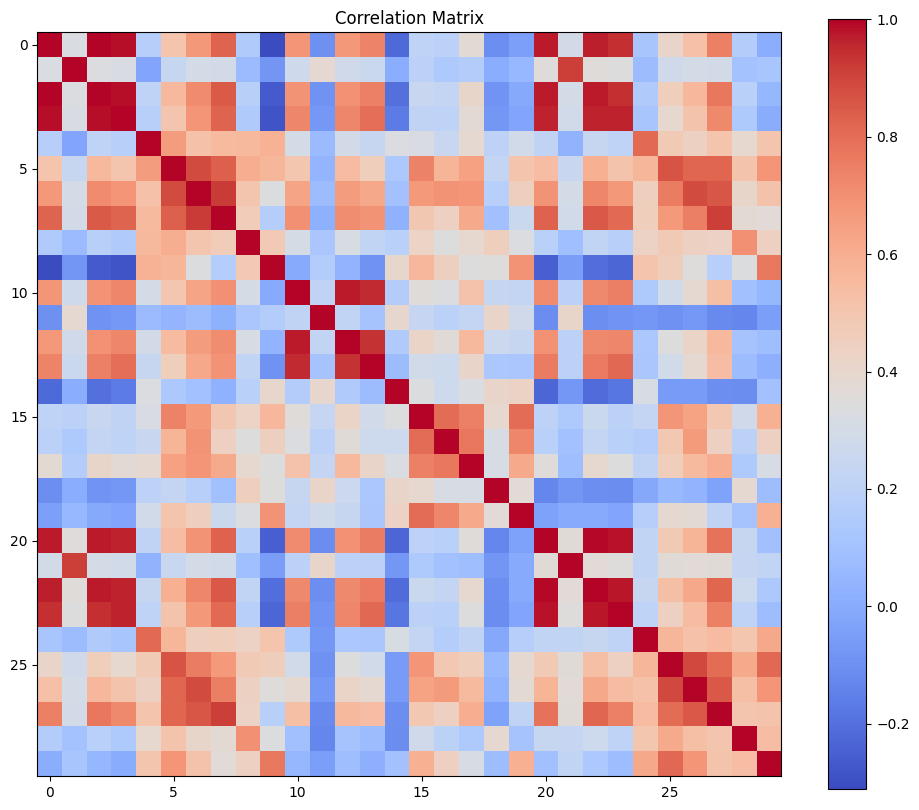

In [ ]:
plt.figure(figsize=(12,10))
corr = X.corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [ ]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)

In [ ]:
coef_df = pd.DataFrame({
    "Fitur":X.columns,
    "Koefisien":log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

coef_df.head(10)

,Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


=== Logistic Regression ===

Confusion Matrix
[[41  1]
 [ 1 71]]


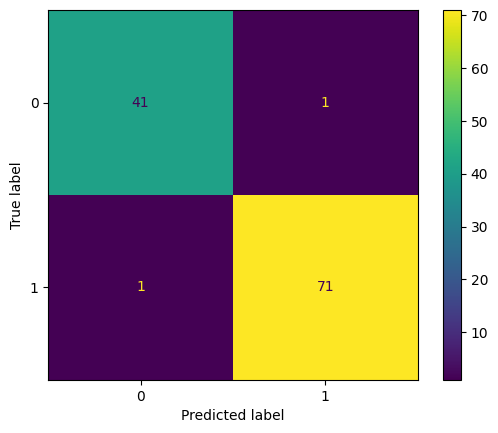


Accuracy : 0.9824561403508771
Precision : 0.9861111111111112
Recall : 0.9861111111111112
F1 Score : 0.9861111111111112

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
print("=== Logistic Regression ===")

print("\nConfusion Matrix")

cm = confusion_matrix(y_test,y_pred_log)

print(cm)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

print("\nAccuracy :",accuracy_score(y_test,y_pred_log))

print("Precision :",precision_score(y_test,y_pred_log))

print("Recall :",recall_score(y_test,y_pred_log))

print("F1 Score :",f1_score(y_test,y_pred_log))

print("\nClassification Report")

print(classification_report(y_test,y_pred_log))

In [ ]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train,y_train)

y_pred_tree = tree_model.predict(X_test)

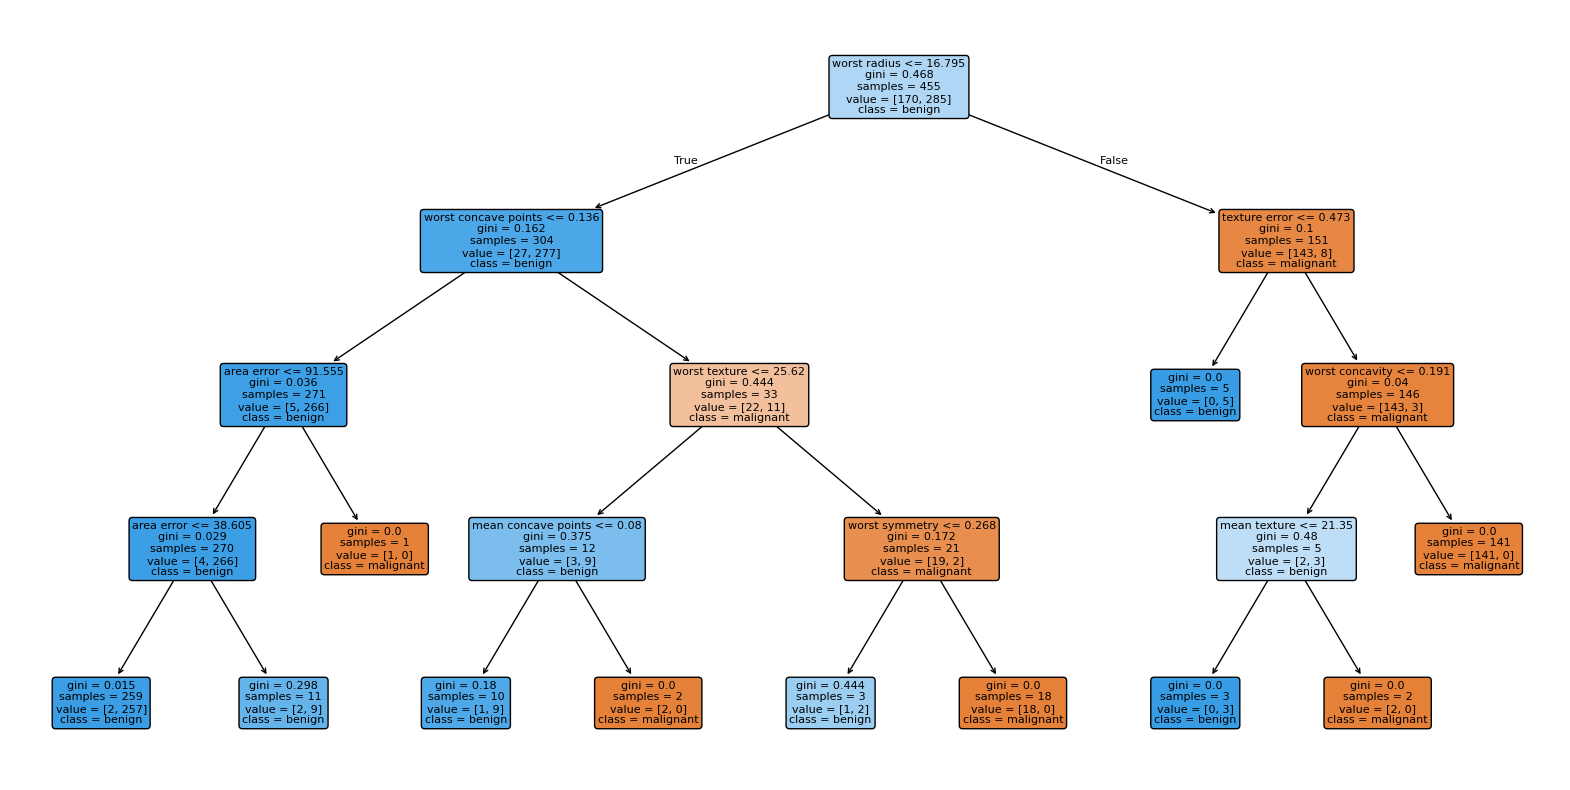

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":tree_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


=== Decision Tree ===
[[39  3]
 [ 4 68]]


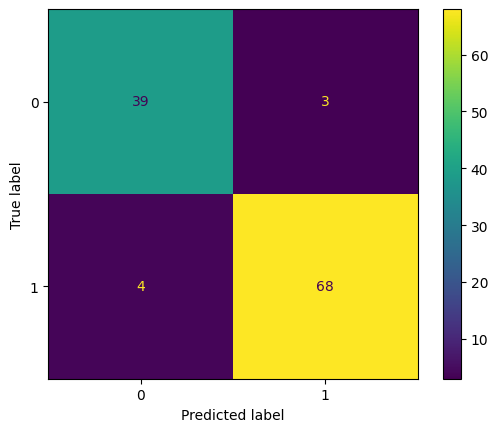

Accuracy : 0.9385964912280702
Precision : 0.9577464788732394
Recall : 0.9444444444444444
F1 Score : 0.951048951048951
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [ ]:
print("=== Decision Tree ===")

cm = confusion_matrix(y_test,y_pred_tree)

print(cm)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

print("Accuracy :",accuracy_score(y_test,y_pred_tree))

print("Precision :",precision_score(y_test,y_pred_tree))

print("Recall :",recall_score(y_test,y_pred_tree))

print("F1 Score :",f1_score(y_test,y_pred_tree))

print(classification_report(y_test,y_pred_tree))

In [ ]:
hasil = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_tree)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_tree)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_tree)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_tree)
    ]

})

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


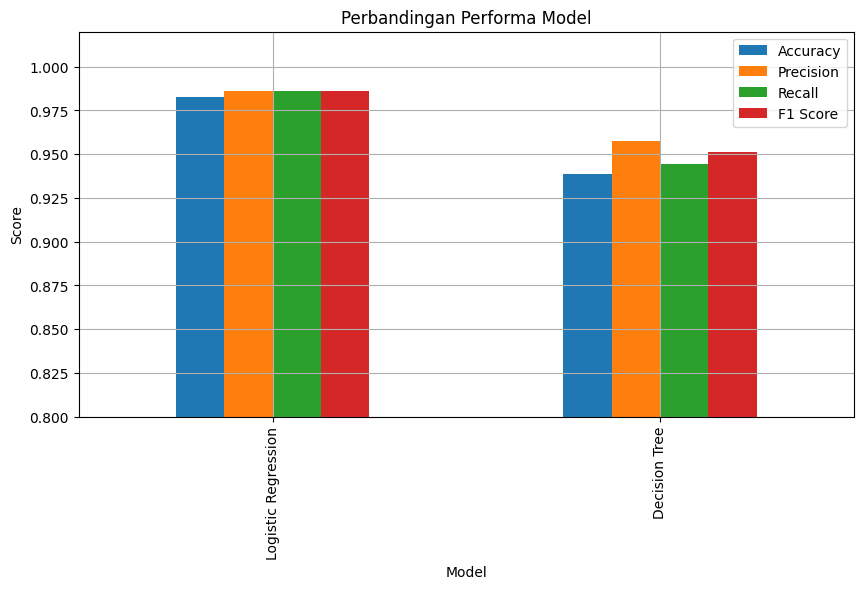

In [ ]:
hasil.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylim(0.8,1.02)

plt.title("Perbandingan Performa Model")

plt.ylabel("Score")

plt.grid(True)

plt.show()

# Kesimpulan

Berdasarkan hasil pengujian menggunakan Breast Cancer Wisconsin Dataset diperoleh dua model klasifikasi yaitu Logistic Regression dan Decision Tree.

Logistic Regression memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi dibandingkan Decision Tree.

Pada kasus diagnosis kanker, metrik yang paling penting adalah Recall karena bertujuan meminimalkan False Negative. False Negative berarti pasien yang sebenarnya menderita kanker diprediksi sehat sehingga berpotensi terlambat mendapatkan penanganan medis.

Model Logistic Regression menghasilkan Recall yang lebih tinggi sehingga lebih mampu mendeteksi pasien yang benar-benar menderita kanker dibandingkan Decision Tree.

Oleh karena itu, Logistic Regression merupakan model yang lebih direkomendasikan untuk kasus prediksi diagnosis kanker payudara pada dataset Breast Cancer Wisconsin.